# Chapter 5: learning multiple weights at a time: generalizing gradient descent

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- Gradient descent learning with multiple inputs
- Freezing one weight: what does it do?
- Gradient descent learning with multiple outputs
- Gradient descent learning with multiple inputs and outputs
- Visualizing weight values
- Visualizing dot products

## Gradient descent learning with multiple inputs

Gradient descent juga bekerja dengan multiple inputs.

Pada chapter sebelumnya, gradient descent digunakan untuk memperbarui satu weight. Pada chapter ini, teknik yang sama digunakan untuk memperbarui network yang memiliki multiple weights.

Network dengan multiple inputs menerima beberapa data sekaligus, lalu menghasilkan satu prediction. Dalam contoh ini, input terdiri dari tiga nilai: `toes`, `wlrec`, dan `nfans`. Ketiganya dipakai untuk memprediksi apakah tim menang.

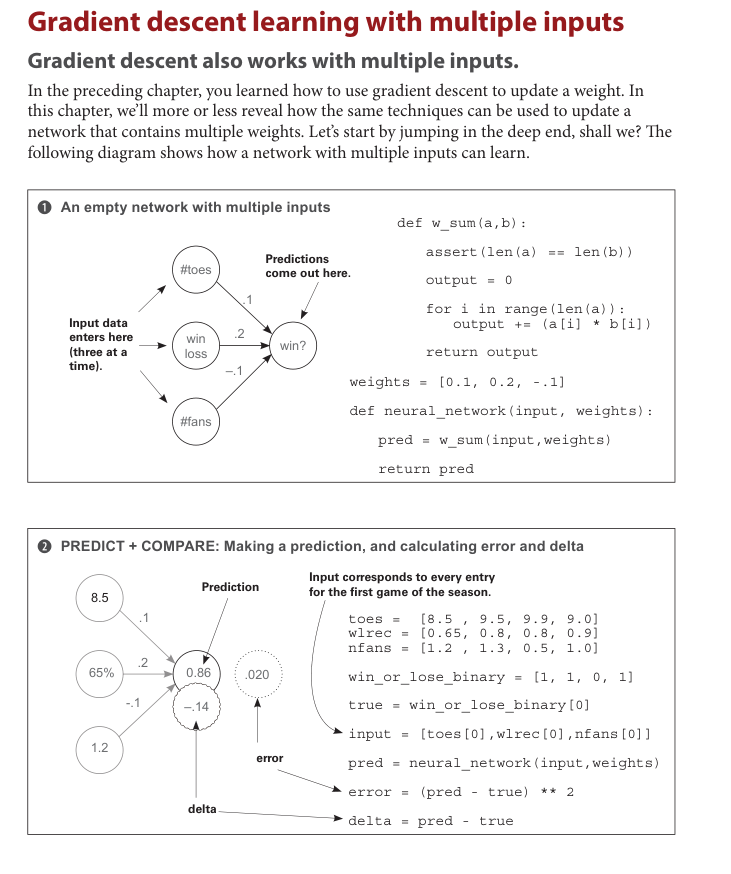

In [1]:
def w_sum(a, b):
  assert(len(a) == len(b))
  output = 0

  for i in range(len(a)):
    output += (a[i] * b[i])

  return output

def neural_network(input, weights):
  pred = w_sum(input, weights)
  return pred

weights = [0.1, 0.2, -0.1]

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]

true = win_or_lose_binary[0]
input = [toes[0], wlrec[0], nfans[0]]

pred = neural_network(input, weights)
error = (pred - true) ** 2
delta = pred - true

print("Prediction:", pred)
print("Error:", error)
print("Delta:", delta)

Prediction: 0.8600000000000001
Error: 0.01959999999999997
Delta: -0.1399999999999999


Setiap `weight_delta` dihitung dengan mengambil output `delta` lalu mengalikannya dengan input dari weight tersebut. Karena tiga weights berbagi output node yang sama, ketiganya juga berbagi `delta` yang sama. Namun, masing-masing memiliki `weight_delta` berbeda karena nilai input-nya berbeda.

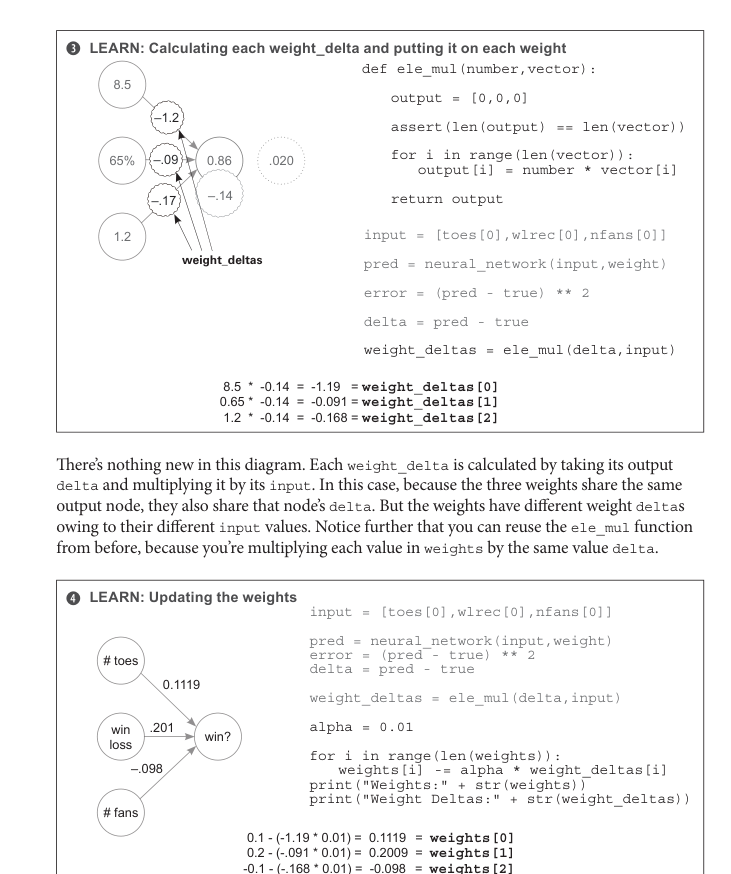

In [2]:
def ele_mul(number, vector):
  output = [0 for _ in range(len(vector))]

  for i in range(len(vector)):
    output[i] = number * vector[i]

  return output

weight_deltas = ele_mul(delta, input)

alpha = 0.01

for i in range(len(weights)):
  weights[i] -= alpha * weight_deltas[i]

print("Weights:", weights)
print("Weight Deltas:", weight_deltas)

Weights: [0.1119, 0.20091, -0.09832]
Weight Deltas: [-1.189999999999999, -0.09099999999999994, -0.16799999999999987]


Pada potongan kode di buku, bagian ini sempat menulis `pred = neural_network(input, weight)`. Variabel yang benar adalah `weights`, karena network ini memakai beberapa weight.

## Gradient descent with multiple inputs explained

Dibandingkan dengan neural network satu weight, gradient descent dengan multiple inputs terlihat mirip. Sampai pembuatan `delta` pada output node, single input dan multi-input gradient descent sama: network membuat prediction, menghitung error, lalu menghitung delta.

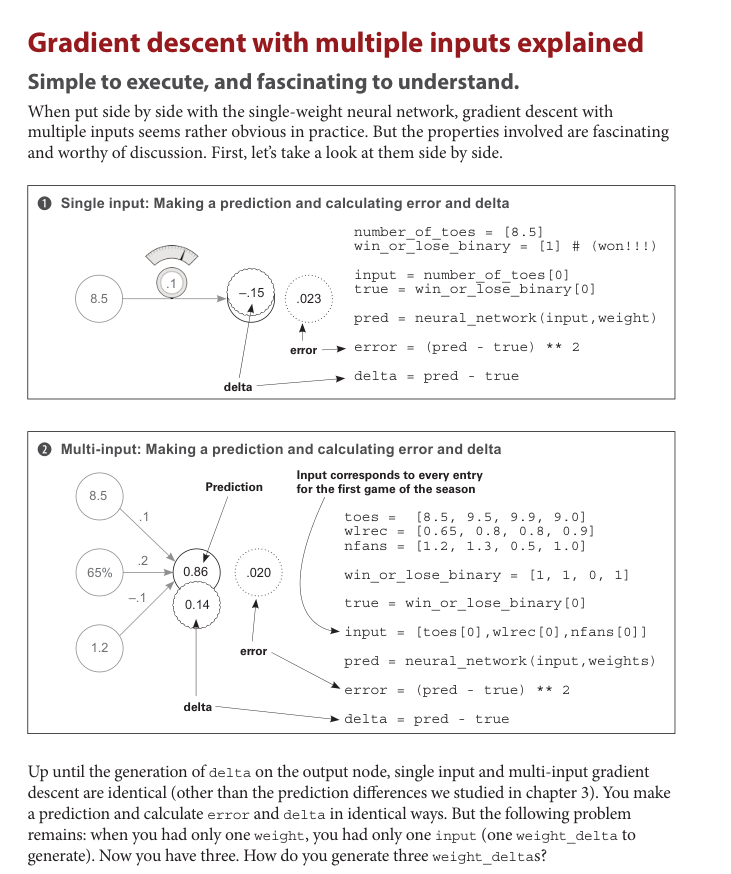

Perbedaannya adalah jumlah `weight_delta`. Pada network satu weight, hanya ada satu input dan satu `weight_delta`. Pada network multiple inputs, ada tiga weights, sehingga perlu tiga `weight_delta`.

`delta` adalah ukuran seberapa tinggi atau rendah nilai node perlu berubah agar prediction sempurna untuk training example saat ini.

`weight_delta` adalah estimasi berbasis derivative tentang arah dan jumlah perubahan weight yang diperlukan untuk mengurangi `node_delta`. Untuk mengubah `delta` menjadi `weight_delta`, `delta` dikalikan dengan input dari weight tersebut.

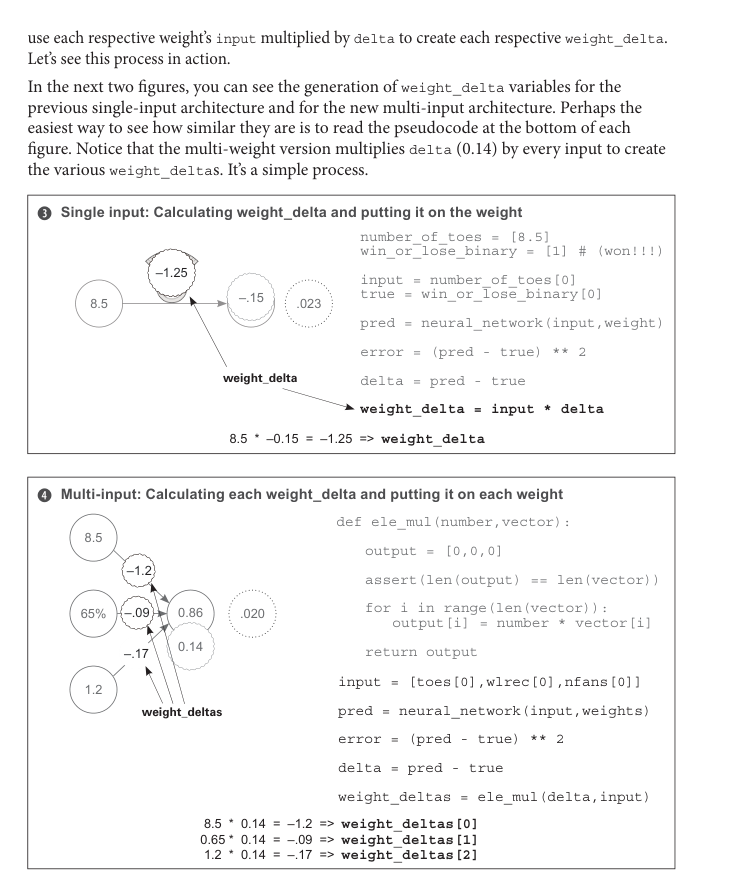

Dengan multiple inputs, satu `delta` output diubah menjadi beberapa `weight_delta` dengan cara mengalikannya dengan input masing-masing weight. Prosesnya tetap sederhana.

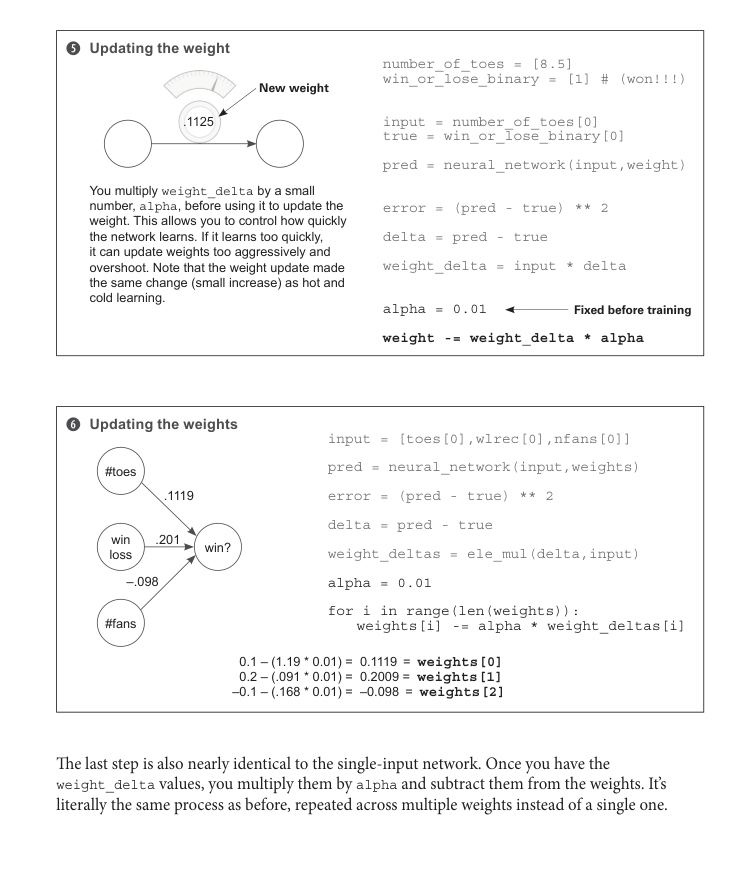

Setelah `weight_delta` diperoleh, setiap `weight_delta` dikalikan dengan `alpha`, lalu dikurangkan dari weight masing-masing. Proses ini sama dengan network single input, hanya diulang untuk beberapa weights.

## Let’s watch several steps of learning

Kode berikut menjalankan beberapa langkah learning pada network multiple inputs.

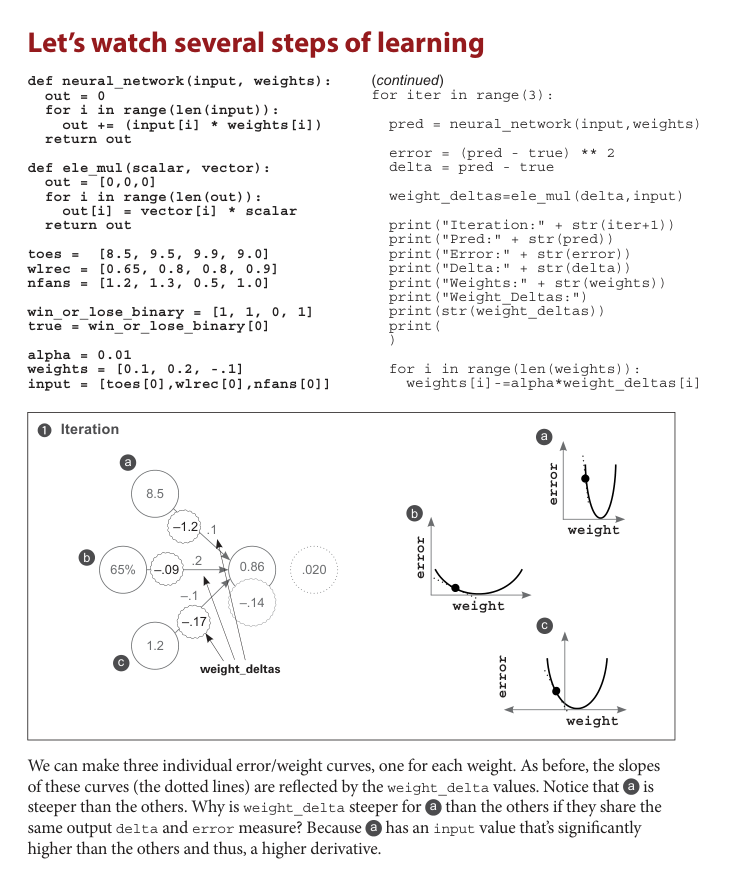

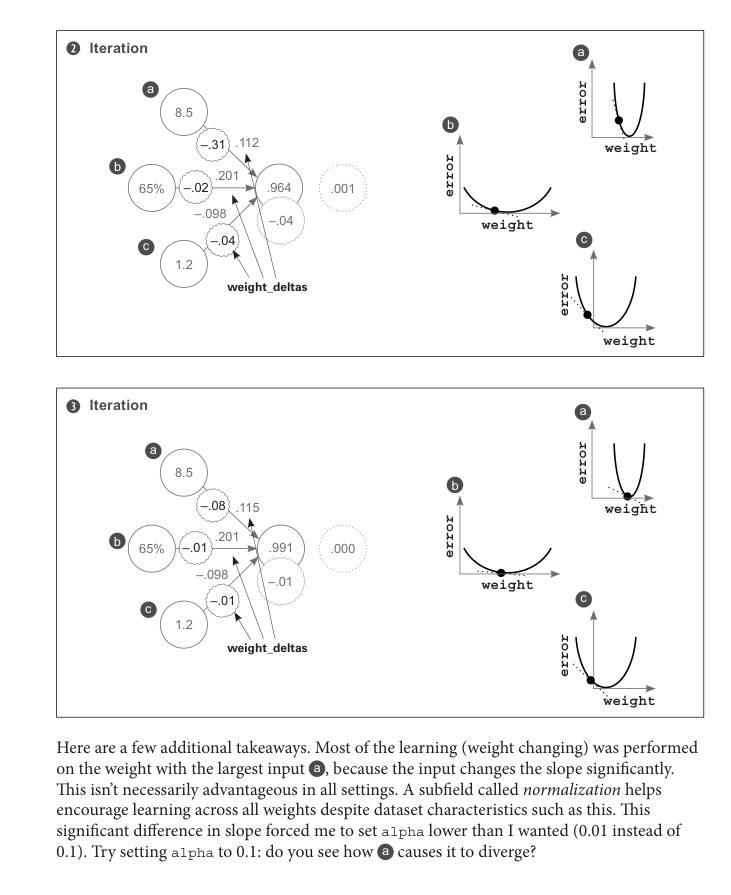

In [3]:
def neural_network(input, weights):
  out = 0

  for i in range(len(input)):
    out += input[i] * weights[i]

  return out

def ele_mul(scalar, vector):
  out = [0 for _ in range(len(vector))]

  for i in range(len(out)):
    out[i] = vector[i] * scalar

  return out

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]

true = win_or_lose_binary[0]
alpha = 0.01
weights = [0.1, 0.2, -0.1]
input = [toes[0], wlrec[0], nfans[0]]

for iter in range(3):
  pred = neural_network(input, weights)
  error = (pred - true) ** 2
  delta = pred - true
  weight_deltas = ele_mul(delta, input)

  print("Iteration:" + str(iter + 1))
  print("Pred:" + str(pred))
  print("Error:" + str(error))
  print("Delta:" + str(delta))
  print("Weights:" + str(weights))
  print("Weight_Deltas:")
  print(str(weight_deltas))
  print()

  for i in range(len(weights)):
    weights[i] -= alpha * weight_deltas[i]

Iteration:1
Pred:0.8600000000000001
Error:0.01959999999999997
Delta:-0.1399999999999999
Weights:[0.1, 0.2, -0.1]
Weight_Deltas:
[-1.189999999999999, -0.09099999999999994, -0.16799999999999987]

Iteration:2
Pred:0.9637574999999999
Error:0.0013135188062500048
Delta:-0.036242500000000066
Weights:[0.1119, 0.20091, -0.09832]
Weight_Deltas:
[-0.30806125000000056, -0.023557625000000044, -0.04349100000000008]

Iteration:3
Pred:0.9906177228125002
Error:8.802712522307997e-05
Delta:-0.009382277187499843
Weights:[0.11498061250000001, 0.20114557625, -0.09788509000000001]
Weight_Deltas:
[-0.07974935609374867, -0.006098480171874899, -0.011258732624999811]



Sebagian besar learning terjadi pada weight dengan input terbesar, karena input yang besar membuat slope lebih curam. Ini tidak selalu menguntungkan. Normalization membantu mendorong learning pada semua weights walaupun karakteristik dataset berbeda.

Perbedaan slope yang besar membuat alpha perlu dibuat lebih rendah. Pada contoh ini alpha dipakai `0.01`.

Latihan pada bagian ini adalah mencoba `alpha = 0.1` untuk melihat weight dengan input besar menyebabkan divergence.

In [4]:
def run_multi_input_learning(alpha, iterations=5):
  def neural_network(input, weights):
    out = 0

    for i in range(len(input)):
      out += input[i] * weights[i]

    return out

  def ele_mul(scalar, vector):
    out = [0 for _ in range(len(vector))]

    for i in range(len(out)):
      out[i] = vector[i] * scalar

    return out

  toes = [8.5, 9.5, 9.9, 9.0]
  wlrec = [0.65, 0.8, 0.8, 0.9]
  nfans = [1.2, 1.3, 0.5, 1.0]
  win_or_lose_binary = [1, 1, 0, 1]

  true = win_or_lose_binary[0]
  weights = [0.1, 0.2, -0.1]
  input = [toes[0], wlrec[0], nfans[0]]

  print("Alpha:", alpha)

  for iter in range(iterations):
    pred = neural_network(input, weights)
    error = (pred - true) ** 2
    delta = pred - true
    weight_deltas = ele_mul(delta, input)

    print("Iteration:" + str(iter + 1))
    print("Pred:" + str(pred))
    print("Error:" + str(error))
    print("Weights:" + str(weights))
    print("Weight_Deltas:" + str(weight_deltas))
    print()

    for i in range(len(weights)):
      weights[i] -= alpha * weight_deltas[i]

run_multi_input_learning(alpha=0.1, iterations=5)

Alpha: 0.1
Iteration:1
Pred:0.8600000000000001
Error:0.01959999999999997
Weights:[0.1, 0.2, -0.1]
Weight_Deltas:[-1.189999999999999, -0.09099999999999994, -0.16799999999999987]

Iteration:2
Pred:1.8975749999999993
Error:0.8056408806249988
Weights:[0.21899999999999992, 0.2091, -0.08320000000000002]
Weight_Deltas:[7.629387499999995, 0.5834237499999996, 1.0770899999999992]

Iteration:3
Pred:-4.754577718749997
Error:33.115164721133915
Weights:[-0.5439387499999997, 0.15075762500000006, -0.19090899999999994]
Weight_Deltas:[-48.91391060937497, -3.740475517187498, -6.905493262499996]

Iteration:4
Pred:37.89403639933592
Error:1361.1699218355236
Weights:[4.347452310937498, 0.5248051767187498, 0.4996403262499997]
Weight_Deltas:[313.5993093943553, 23.981123659568347, 44.2728436792031]

Iteration:5
Pred:-235.53689086524244
Error:55949.700740195614
Weights:[-27.012478628498034, -1.873307189238085, -3.9276440416703107]
Weight_Deltas:[-2010.5635723545608, -153.74897906240759, -283.8442690382909]



## Freezing one weight: What does it do?

Eksperimen ini melatih network lagi, tetapi weight pertama tidak pernah disesuaikan. Network mencoba belajar training example hanya dengan `weights[1]` dan `weights[2]`.

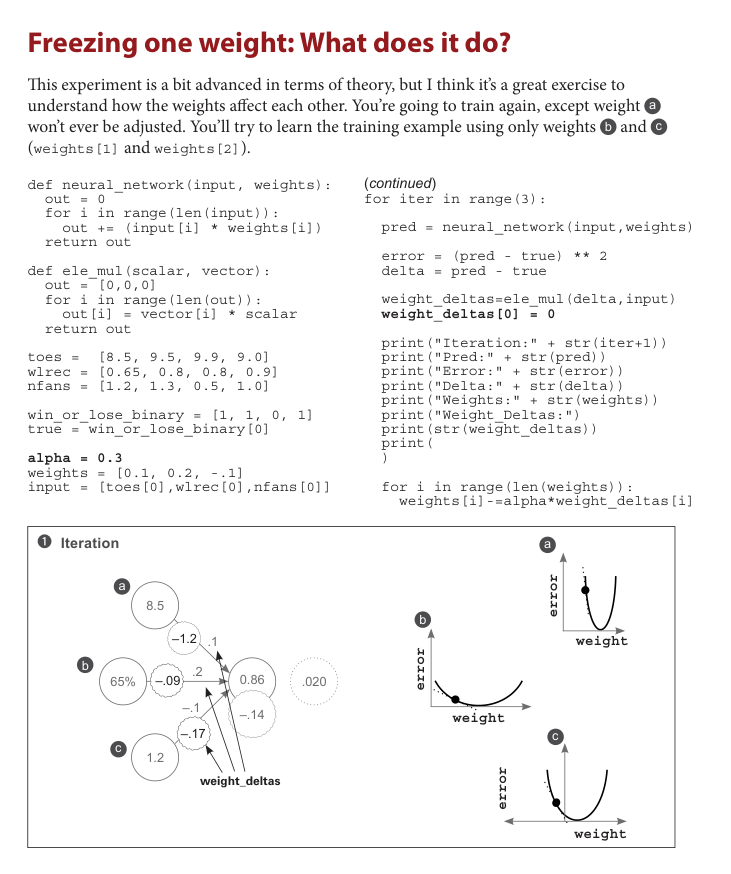

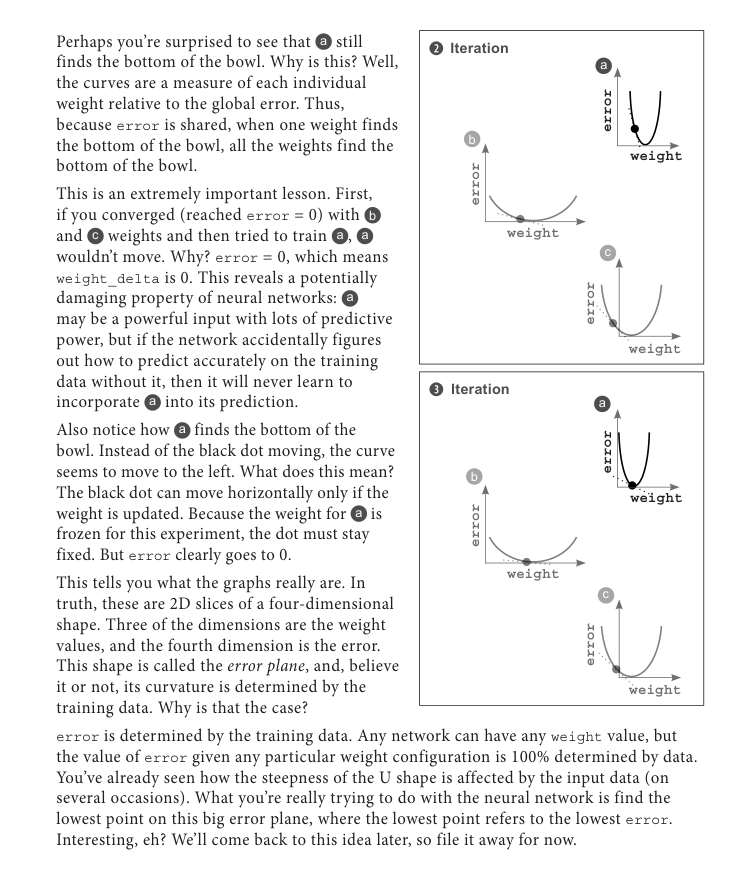

In [5]:
def neural_network(input, weights):
  out = 0

  for i in range(len(input)):
    out += input[i] * weights[i]

  return out

def ele_mul(scalar, vector):
  out = [0 for _ in range(len(vector))]

  for i in range(len(out)):
    out[i] = vector[i] * scalar

  return out

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]

true = win_or_lose_binary[0]
alpha = 0.3
weights = [0.1, 0.2, -0.1]
input = [toes[0], wlrec[0], nfans[0]]

for iter in range(3):
  pred = neural_network(input, weights)
  error = (pred - true) ** 2
  delta = pred - true
  weight_deltas = ele_mul(delta, input)

  weight_deltas[0] = 0

  print("Iteration:" + str(iter + 1))
  print("Pred:" + str(pred))
  print("Error:" + str(error))
  print("Delta:" + str(delta))
  print("Weights:" + str(weights))
  print("Weight_Deltas:")
  print(str(weight_deltas))
  print()

  for i in range(len(weights)):
    weights[i] -= alpha * weight_deltas[i]

Iteration:1
Pred:0.8600000000000001
Error:0.01959999999999997
Delta:-0.1399999999999999
Weights:[0.1, 0.2, -0.1]
Weight_Deltas:
[0, -0.09099999999999994, -0.16799999999999987]

Iteration:2
Pred:0.9382250000000001
Error:0.003816150624999989
Delta:-0.06177499999999991
Weights:[0.1, 0.2273, -0.04960000000000005]
Weight_Deltas:
[0, -0.040153749999999946, -0.07412999999999989]

Iteration:3
Pred:0.97274178125
Error:0.000743010489422852
Delta:-0.027258218750000007
Weights:[0.1, 0.239346125, -0.02736100000000008]
Weight_Deltas:
[0, -0.017717842187500006, -0.032709862500000006]



Karena error dibagi bersama oleh semua weights, ketika beberapa weights berhasil membuat error menjadi 0, semua weight seolah ikut menemukan dasar error curve.

Ini penting karena sebuah input bisa saja sangat kuat, tetapi jika network berhasil memprediksi training data secara akurat tanpa input tersebut, network tidak akan pernah belajar memasukkan input itu ke prediction. Saat error sudah 0, `weight_delta` juga 0, sehingga weight tidak bergerak.

Grafik yang terlihat sebenarnya adalah potongan 2D dari bentuk empat dimensi: tiga dimensi untuk nilai weights dan satu dimensi untuk error. Bentuk ini disebut error plane. Curvature dari error plane ditentukan oleh training data.

## Gradient descent learning with multiple outputs

Neural networks juga dapat membuat multiple predictions menggunakan satu input.

Setiap delta dihitung dengan cara yang sama. Lalu semua delta dikalikan dengan single input yang sama untuk menghasilkan `weight_delta` tiap weight.

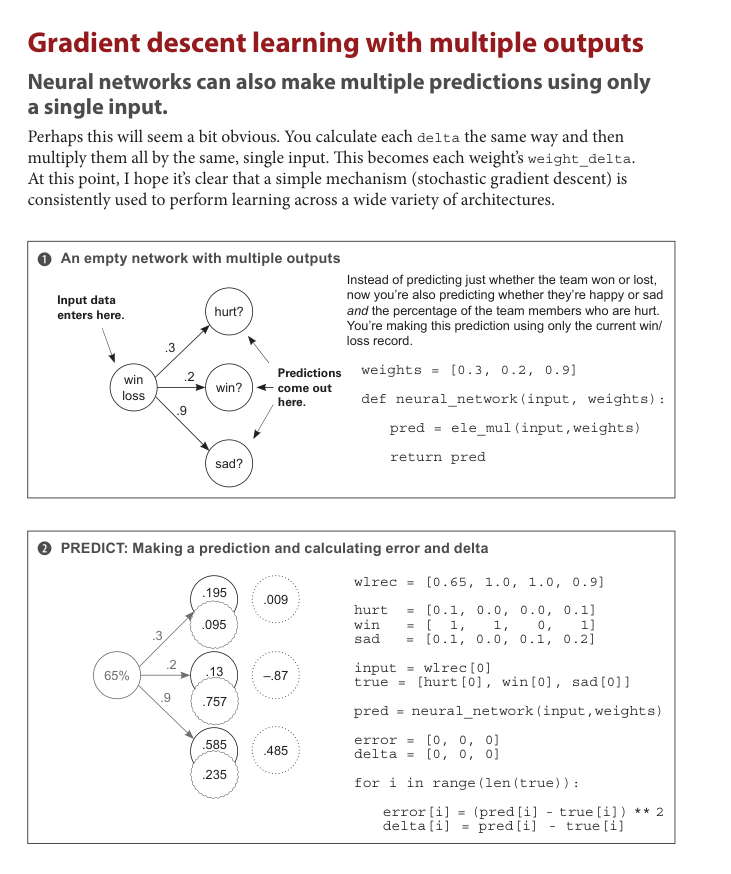

In [6]:
def scalar_ele_mul(number, vector):
  output = [0 for _ in range(len(vector))]

  for i in range(len(vector)):
    output[i] = number * vector[i]

  return output

def neural_network(input, weights):
  pred = scalar_ele_mul(input, weights)
  return pred

weights = [0.3, 0.2, 0.9]

wlrec = [0.65, 1.0, 1.0, 0.9]
hurt = [0.1, 0.0, 0.0, 0.1]
win = [1, 1, 0, 1]
sad = [0.1, 0.0, 0.1, 0.2]

input = wlrec[0]
true = [hurt[0], win[0], sad[0]]

pred = neural_network(input, weights)

error = [0, 0, 0]
delta = [0, 0, 0]

for i in range(len(true)):
  error[i] = (pred[i] - true[i]) ** 2
  delta[i] = pred[i] - true[i]

print("Prediction:", pred)
print("Error:", error)
print("Delta:", delta)

Prediction: [0.195, 0.13, 0.5850000000000001]
Error: [0.009025, 0.7569, 0.2352250000000001]
Delta: [0.095, -0.87, 0.4850000000000001]


Pada bagian compare, `weight_deltas` dihitung dengan mengalikan input node value dengan output node delta untuk setiap weight.

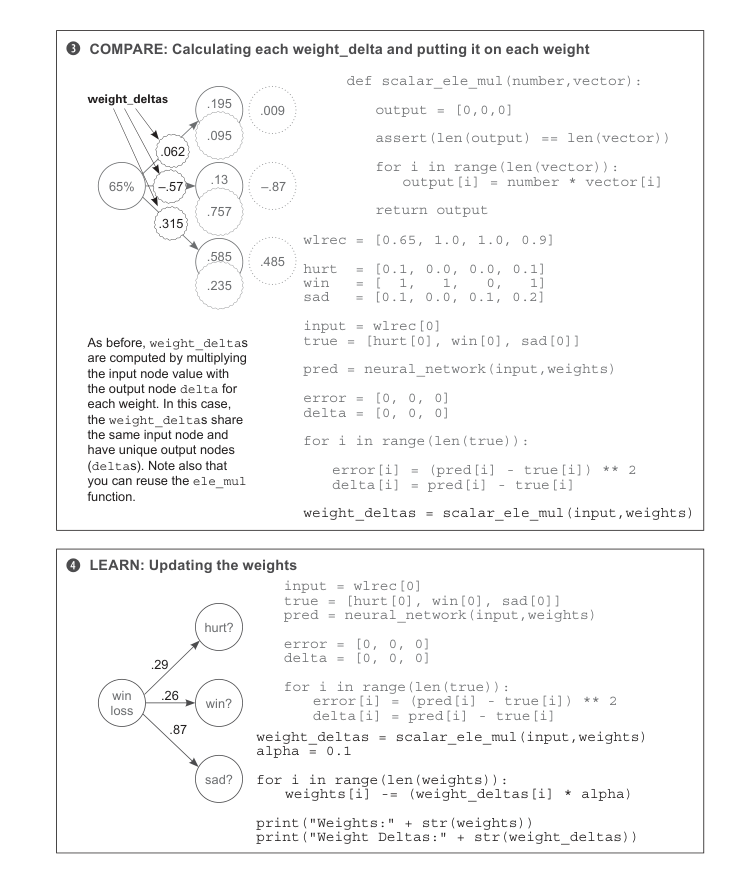

In [7]:
weight_deltas = scalar_ele_mul(input, delta)

alpha = 0.1

for i in range(len(weights)):
  weights[i] -= weight_deltas[i] * alpha

print("Weights:", weights)
print("Weight Deltas:", weight_deltas)

Weights: [0.293825, 0.25655, 0.868475]
Weight Deltas: [0.061750000000000006, -0.5655, 0.3152500000000001]


Pada potongan kode buku, bagian ini tertulis `weight_deltas = scalar_ele_mul(input, weights)`. Agar sesuai dengan penjelasan dan dapat belajar dari error, notebook ini memakai `delta`, bukan `weights`.

## Gradient descent with multiple inputs and outputs

Gradient descent dapat digeneralisasi ke network yang lebih besar.

Network pada bagian ini menerima multiple inputs dan menghasilkan multiple outputs. Setiap output memiliki weighted sum sendiri terhadap input.

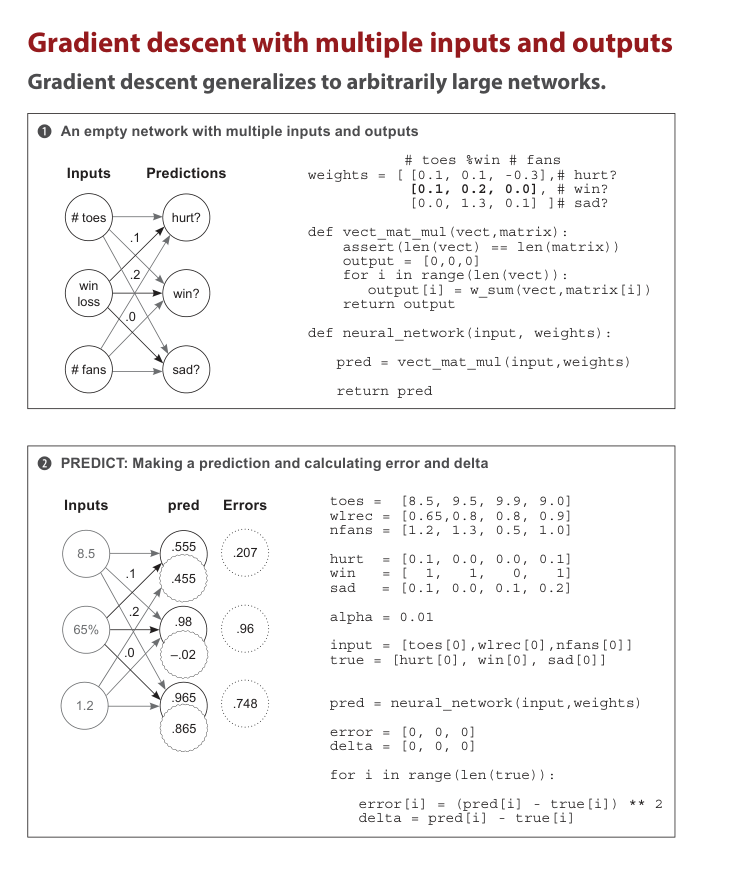

In [8]:
def w_sum(a, b):
  assert(len(a) == len(b))
  output = 0

  for i in range(len(a)):
    output += a[i] * b[i]

  return output

def vect_mat_mul(vect, matrix):
  output = [0 for _ in range(len(matrix))]

  for i in range(len(matrix)):
    output[i] = w_sum(vect, matrix[i])

  return output

def neural_network(input, weights):
  pred = vect_mat_mul(input, weights)
  return pred

weights = [
  [0.1, 0.1, -0.3], # hurt?
  [0.1, 0.2, 0.0],  # win?
  [0.0, 1.3, 0.1]   # sad?
]

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

hurt = [0.1, 0.0, 0.0, 0.1]
win = [1, 1, 0, 1]
sad = [0.1, 0.0, 0.1, 0.2]

alpha = 0.01

input = [toes[0], wlrec[0], nfans[0]]
true = [hurt[0], win[0], sad[0]]

pred = neural_network(input, weights)

error = [0, 0, 0]
delta = [0, 0, 0]

for i in range(len(true)):
  error[i] = (pred[i] - true[i]) ** 2
  delta[i] = pred[i] - true[i]

print("Prediction:", pred)
print("Error:", error)
print("Delta:", delta)

Prediction: [0.555, 0.9800000000000001, 0.9650000000000001]
Error: [0.20702500000000007, 0.0003999999999999963, 0.7482250000000001]
Delta: [0.45500000000000007, -0.019999999999999907, 0.8650000000000001]


Untuk multiple inputs dan outputs, `weight_deltas` dibentuk sebagai outer product antara `delta` dan `input`. Setiap output delta dikalikan dengan setiap input.

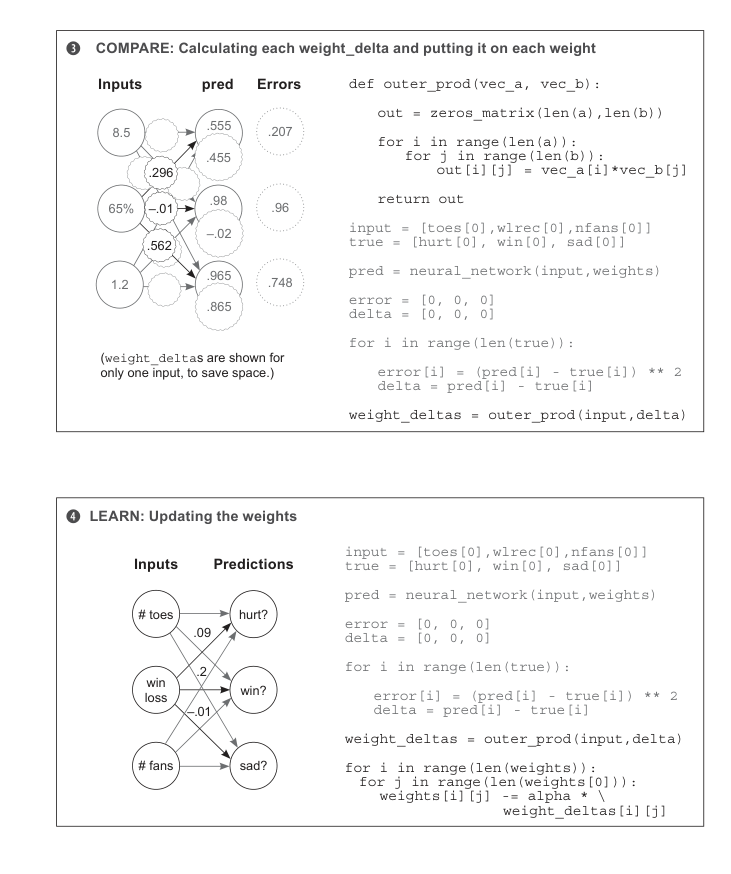

In [9]:
def zeros_matrix(rows, cols):
  output = []

  for row in range(rows):
    output.append([0 for _ in range(cols)])

  return output

def outer_prod(vec_a, vec_b):
  out = zeros_matrix(len(vec_a), len(vec_b))

  for i in range(len(vec_a)):
    for j in range(len(vec_b)):
      out[i][j] = vec_a[i] * vec_b[j]

  return out

weight_deltas = outer_prod(delta, input)

for i in range(len(weights)):
  for j in range(len(weights[0])):
    weights[i][j] -= alpha * weight_deltas[i][j]

print("Weight Deltas:")
for row in weight_deltas:
  print(row)

print("Updated Weights:")
for row in weights:
  print(row)

Weight Deltas:
[3.8675000000000006, 0.29575000000000007, 0.546]
[-0.1699999999999992, -0.01299999999999994, -0.023999999999999886]
[7.352500000000001, 0.5622500000000001, 1.038]
Updated Weights:
[0.061325, 0.0970425, -0.30546]
[0.1017, 0.20013, 0.00023999999999999887]
[-0.07352500000000001, 1.2943775, 0.08962]


Pada potongan kode buku, fungsi `outer_prod` memakai `len(a)` dan `len(b)`, padahal parameter fungsinya adalah `vec_a` dan `vec_b`. Notebook ini memakai nama parameter yang benar.

Pada potongan predict, bagian `delta = pred[i] - true[i]` perlu menjadi `delta[i] = pred[i] - true[i]` agar semua output delta tersimpan.

Bentuk `weights` pada notebook ini mengikuti susunan row per output. Karena itu outer product dihitung sebagai `outer_prod(delta, input)` agar ukuran `weight_deltas` sama dengan ukuran `weights`.

## What do these weights learn?

Bagian ini berpindah ke dataset dunia nyata pertama, yaitu MNIST.

MNIST adalah dataset angka tulisan tangan. Setiap image adalah gambar hitam putih berukuran 28 × 28 pixel, sehingga satu image memiliki 784 pixel. Setiap image memiliki label angka sebenarnya dari 0 sampai 9.

Karena ada 784 pixel sebagai input dan 10 kemungkinan label sebagai output, neural network memiliki 784 input values dan 10 output values. Setiap output merepresentasikan satu kemungkinan digit.

Untuk memasukkan image 28 × 28 ke neural network yang flat, image diubah menjadi vector 1 × 784. Baris pixel pertama digabung dengan baris kedua, ketiga, dan seterusnya sampai menjadi satu daftar pixel sepanjang 784 untuk setiap image.

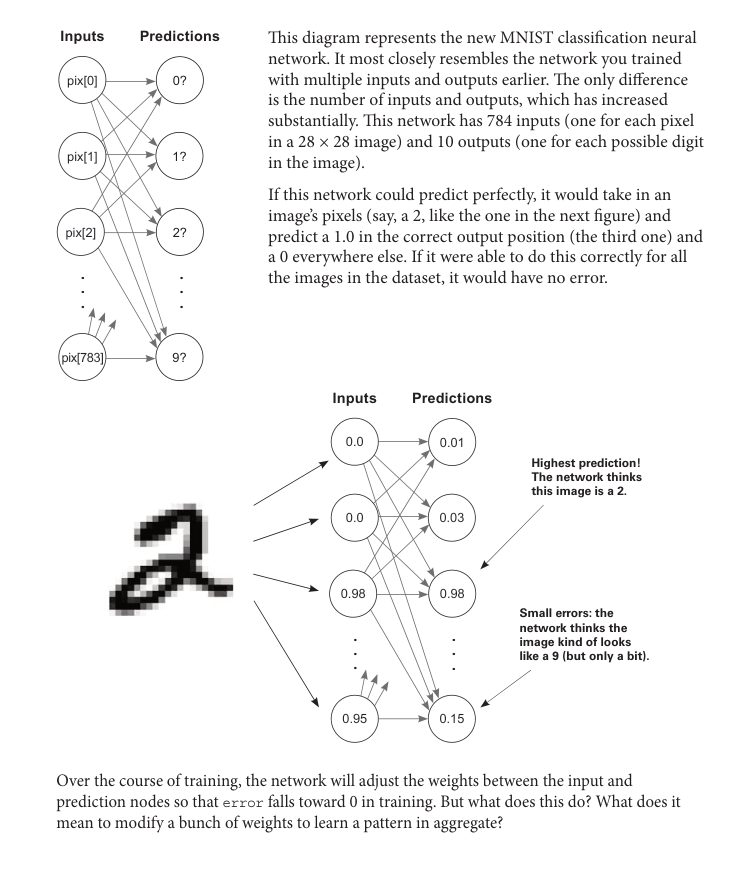

Jika network dapat memprediksi dengan sempurna, image angka 2 akan menghasilkan nilai 1.0 pada output untuk angka 2 dan 0 pada output lainnya. Selama training, network menyesuaikan weights antara input dan prediction nodes agar error turun menuju 0.

## Visualizing weight values

Pada riset neural network, terutama image classifier, weights dapat divisualisasikan seperti image.

Setiap output node memiliki weight dari setiap pixel. Misalnya node `2?` memiliki 784 input weights, masing-masing memetakan hubungan antara pixel dan angka 2.

Jika weight tinggi, model menganggap pixel tersebut memiliki korelasi tinggi dengan angka 2. Jika weight sangat rendah atau negatif, network menganggap korelasinya rendah atau negatif dengan angka 2.

Jika weights dicetak kembali ke bentuk image yang sama dengan input dataset, dapat terlihat pixel mana yang memiliki korelasi paling tinggi dengan output tertentu. Area terang menunjukkan weights tinggi, area gelap menunjukkan weights negatif, dan warna netral menunjukkan nilai 0.

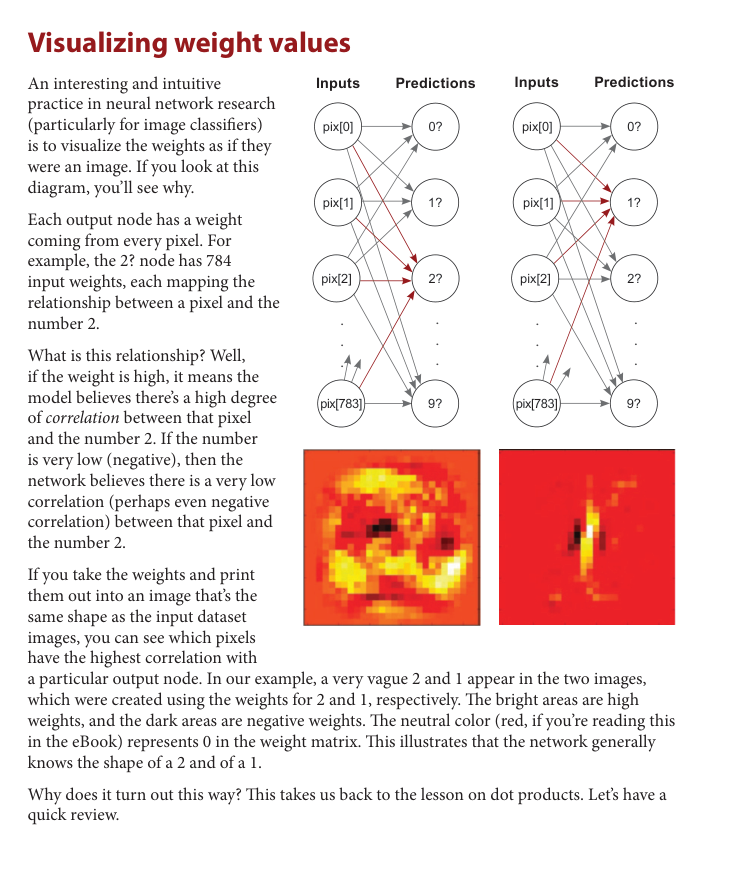

## Visualizing dot products (weighted sums)

Dot product mengambil dua vector, mengalikannya secara elementwise, lalu menjumlahkan hasilnya.

Jika dua vector tidak memiliki nilai positif yang overlap, dot product menghasilkan skor rendah. Jika ada overlap pada kolom bernilai positif, dot product menghasilkan skor lebih tinggi. Dot product antara dua vector identik cenderung menghasilkan skor lebih tinggi.

Kesimpulannya, dot product adalah ukuran kasar similarity antara dua vector.

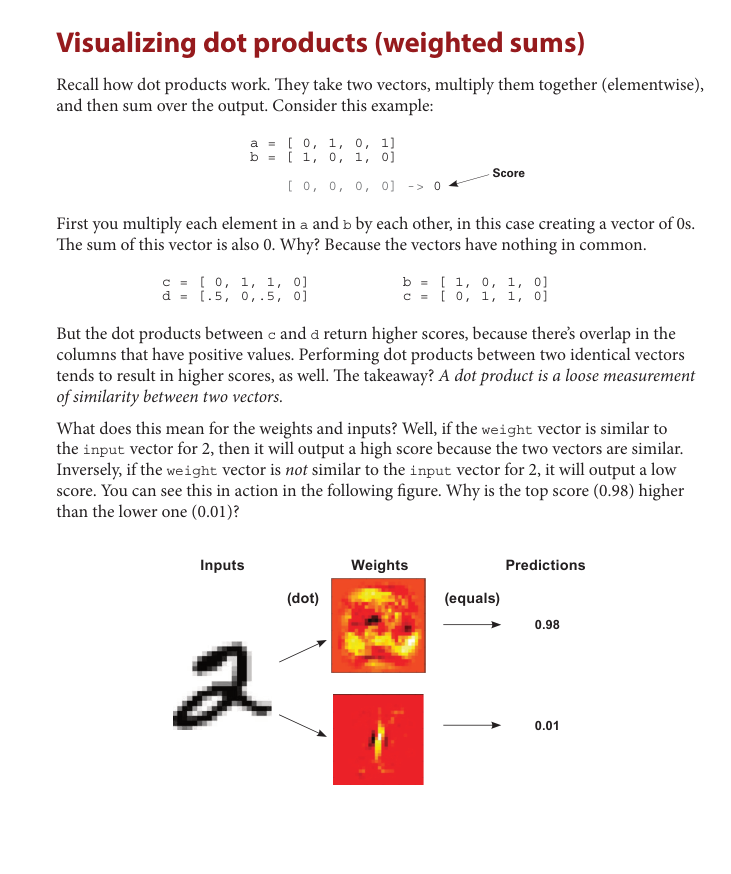

In [10]:
def dot_product(vec_a, vec_b):
  assert(len(vec_a) == len(vec_b))
  output = 0

  for i in range(len(vec_a)):
    output += vec_a[i] * vec_b[i]

  return output

a = [0, 1, 0, 1]
b = [1, 0, 1, 0]
c = [0, 1, 1, 0]
d = [0.5, 0, 0.5, 0]

print("dot_product(a, b):", dot_product(a, b))
print("dot_product(b, c):", dot_product(b, c))
print("dot_product(c, d):", dot_product(c, d))
print("dot_product(c, c):", dot_product(c, c))

dot_product(a, b): 0
dot_product(b, c): 1
dot_product(c, d): 0.5
dot_product(c, c): 2


Jika weight vector mirip dengan input vector untuk angka 2, output score akan tinggi karena kedua vector mirip. Jika weight vector tidak mirip dengan input vector untuk angka 2, output score akan rendah.

## Summary

Gradient descent adalah learning algorithm yang fleksibel.

Jika weights dikombinasikan dengan cara yang memungkinkan error function dan delta dihitung, gradient descent dapat menunjukkan cara menggerakkan weights agar error berkurang. Sisa buku akan mengeksplorasi berbagai kombinasi weights dan error functions yang dapat menggunakan gradient descent.